# Uber Cancellation Prediction - Business Impact Analysis

**Objective:** Translate model performance into business value and provide actionable recommendations.

**Approach:** Calculate revenue impact, define intervention scenarios, and develop implementation roadmap.

---

## Table of Contents
1. [Current Business State](#state)
2. [Revenue Impact](#revenue)
3. [Model Value Proposition](#value)
4. [Intervention Scenarios](#scenarios)
5. [Recommendations](#recommendations)
6. [Implementation Roadmap](#roadmap)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import confusion_matrix

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load model and test data
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

with open('random_forest_model.pkl', 'rb') as f:
    rf = pickle.load(f)

with open('target_encoder.pkl', 'rb') as f:
    target_encoder = pickle.load(f)

# Generate predictions
y_pred = rf.predict(X_test)

class_names = target_encoder.classes_
print(f"Test set size: {len(y_test):,} rides")
print(f"Classes: {class_names}")

Test set size: 24,449 rides
Classes: ['Cancelled by Customer' 'Cancelled by Driver' 'Completed' 'Incomplete'
 'No Driver Found']


## 1. Current Business State

In [3]:
# Calculate current metrics
total_rides = len(y_test)
completed = (y_test == 2).sum()  # Completed is encoded as 2
cancelled_by_driver = (y_test == 1).sum()
cancelled_by_customer = (y_test == 0).sum()
no_driver_found = (y_test == 4).sum()
incomplete = (y_test == 3).sum()

completion_rate = completed / total_rides * 100
total_unsuccessful = total_rides - completed
unsuccessful_rate = total_unsuccessful / total_rides * 100

print("Current State Analysis (Test Set: Nov-Dec 2024)")
print("=" * 60)
print(f"Total rides: {total_rides:,}")
print(f"Completed: {completed:,} ({completion_rate:.1f}%)")
print(f"Unsuccessful: {total_unsuccessful:,} ({unsuccessful_rate:.1f}%)")
print(f"\nBreakdown of unsuccessful rides:")
print(f"  Cancelled by Driver: {cancelled_by_driver:,} ({cancelled_by_driver/total_rides*100:.1f}%)")
print(f"  Cancelled by Customer: {cancelled_by_customer:,} ({cancelled_by_customer/total_rides*100:.1f}%)")
print(f"  No Driver Found: {no_driver_found:,} ({no_driver_found/total_rides*100:.1f}%)")
print(f"  Incomplete: {incomplete:,} ({incomplete/total_rides*100:.1f}%)")

Current State Analysis (Test Set: Nov-Dec 2024)
Total rides: 24,449
Completed: 15,157 (62.0%)
Unsuccessful: 9,292 (38.0%)

Breakdown of unsuccessful rides:
  Cancelled by Driver: 4,397 (18.0%)
  Cancelled by Customer: 1,716 (7.0%)
  No Driver Found: 1,681 (6.9%)
  Incomplete: 1,498 (6.1%)


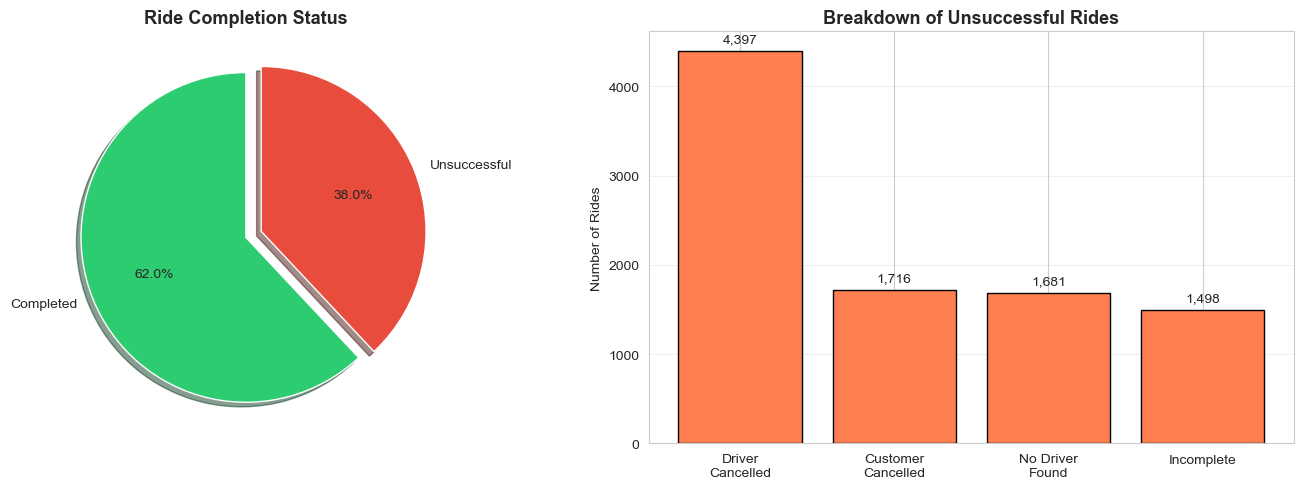

In [4]:
# Visualize current state
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
labels = ['Completed', 'Unsuccessful']
sizes = [completed, total_unsuccessful]
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)

axes[0].pie(sizes, explode=explode, labels=labels, colors=colors,
           autopct='%1.1f%%', shadow=True, startangle=90)
axes[0].set_title('Ride Completion Status', fontsize=13, fontweight='bold')

# Bar chart for unsuccessful breakdown
unsuccessful_types = ['Driver\nCancelled', 'Customer\nCancelled', 
                     'No Driver\nFound', 'Incomplete']
unsuccessful_counts = [cancelled_by_driver, cancelled_by_customer, 
                       no_driver_found, incomplete]

axes[1].bar(unsuccessful_types, unsuccessful_counts, color='coral', edgecolor='black')
axes[1].set_title('Breakdown of Unsuccessful Rides', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Rides')
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(unsuccessful_counts):
    axes[1].text(i, v + 100, f'{v:,}', ha='center')

plt.tight_layout()
plt.savefig('business_state.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Revenue Impact Analysis

In [5]:
# Revenue calculations
avg_revenue_per_ride = 508  # INR from earlier analysis

current_revenue = completed * avg_revenue_per_ride
potential_revenue = total_rides * avg_revenue_per_ride
lost_revenue = potential_revenue - current_revenue

# Annualize (test set is 2 months)
annualized_lost = lost_revenue * 6

print("Revenue Impact Analysis")
print("=" * 60)
print(f"Average revenue per completed ride: Rs.{avg_revenue_per_ride}")
print(f"\nCurrent revenue (2 months): Rs.{current_revenue:,} (Rs.{current_revenue/1_000_000:.2f}M)")
print(f"Potential revenue (2 months): Rs.{potential_revenue:,} (Rs.{potential_revenue/1_000_000:.2f}M)")
print(f"Lost revenue (2 months): Rs.{lost_revenue:,} (Rs.{lost_revenue/1_000_000:.2f}M)")
print(f"\nAnnualized lost revenue: Rs.{annualized_lost/1_000_000:.2f}M")
print(f"Lost revenue as % of potential: {lost_revenue/potential_revenue*100:.1f}%")

Revenue Impact Analysis
Average revenue per completed ride: ₹508

Current revenue (2 months): ₹7,699,756 (₹7.70M)
Potential revenue (2 months): ₹12,420,092 (₹12.42M)
Lost revenue (2 months): ₹4,720,336 (₹4.72M)

Annualized lost revenue: ₹28.32M
Lost revenue as % of potential: 38.0%


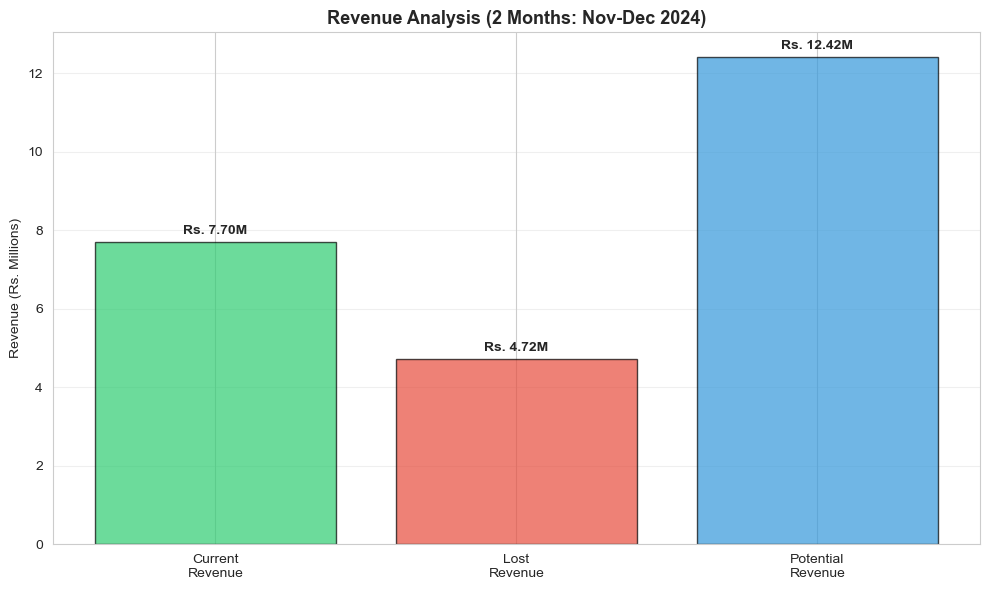

In [8]:
# Visualize revenue impact
plt.figure(figsize=(10, 6))

categories = ['Current\nRevenue', 'Lost\nRevenue', 'Potential\nRevenue']
values = [current_revenue/1_000_000, lost_revenue/1_000_000, potential_revenue/1_000_000]
colors_rev = ['#2ecc71', '#e74c3c', '#3498db']

bars = plt.bar(categories, values, color=colors_rev, edgecolor='black', alpha=0.7)
plt.ylabel('Revenue (Rs. Millions)')
plt.title('Revenue Analysis (2 Months: Nov-Dec 2024)', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(values):
    plt.text(i, v + 0.2, f'Rs. {v:.2f}M', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('revenue_impact.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Model Value Proposition

In [9]:
# Analyze what the model can identify
cm = confusion_matrix(y_test, y_pred)

# Focus on cancellations and no driver found
cancelled_by_customer_idx = 0
cancelled_by_driver_idx = 1
no_driver_found_idx = 4

# True positives
tp_customer = cm[cancelled_by_customer_idx, cancelled_by_customer_idx]
tp_driver = cm[cancelled_by_driver_idx, cancelled_by_driver_idx]
tp_no_driver = cm[no_driver_found_idx, no_driver_found_idx]

# Actual counts
actual_customer = cm[cancelled_by_customer_idx, :].sum()
actual_driver = cm[cancelled_by_driver_idx, :].sum()
actual_no_driver = cm[no_driver_found_idx, :].sum()

# Recall rates
recall_customer = tp_customer / actual_customer
recall_driver = tp_driver / actual_driver
recall_no_driver = tp_no_driver / actual_no_driver

total_high_risk_identified = tp_customer + tp_driver + tp_no_driver
total_high_risk_actual = actual_customer + actual_driver + actual_no_driver
overall_recall = total_high_risk_identified / total_high_risk_actual

print("Model Detection Capability")
print("=" * 60)
print(f"Customer cancellations detected: {tp_customer}/{actual_customer} ({recall_customer*100:.1f}%)")
print(f"Driver cancellations detected: {tp_driver}/{actual_driver} ({recall_driver*100:.1f}%)")
print(f"No driver found detected: {tp_no_driver}/{actual_no_driver} ({recall_no_driver*100:.1f}%)")
print(f"\nTotal high-risk rides identified: {total_high_risk_identified:,}/{total_high_risk_actual:,} ({overall_recall*100:.1f}%)")

Model Detection Capability
Customer cancellations detected: 479/1716 (27.9%)
Driver cancellations detected: 1671/4397 (38.0%)
No driver found detected: 544/1681 (32.4%)

Total high-risk rides identified: 2,694/7,794 (34.6%)


## 4. Intervention Scenarios

Estimate potential impact of interventions based on identified high-risk rides.

In [10]:
# Calculate intervention scenarios
scenarios = {
    'Conservative (20%)': 0.20,
    'Moderate (30%)': 0.30,
    'Optimistic (40%)': 0.40
}

results = []

for scenario_name, save_rate in scenarios.items():
    rides_saved = int(total_high_risk_identified * save_rate)
    revenue_saved_2m = rides_saved * avg_revenue_per_ride
    revenue_saved_annual = revenue_saved_2m * 6
    pct_of_lost = (revenue_saved_annual / annualized_lost) * 100
    
    results.append({
        'Scenario': scenario_name,
        'Rides Saved': rides_saved,
        'Revenue (2M)': revenue_saved_2m / 1_000_000,
        'Revenue (Annual)': revenue_saved_annual / 1_000_000,
        '% of Lost Revenue': pct_of_lost
    })
    
    print(f"{scenario_name}")
    print("-" * 60)
    print(f"  Rides saved: {rides_saved:,}")
    print(f"  Revenue saved (2 months): Rs.{revenue_saved_2m/1_000_000:.2f}M")
    print(f"  Revenue saved (annual): Rs.{revenue_saved_annual/1_000_000:.2f}M")
    print(f"  Recovers {pct_of_lost:.1f}% of lost revenue\n")

results_df = pd.DataFrame(results)
print("\nScenario Comparison:")
print(results_df.to_string(index=False))

Conservative (20%)
------------------------------------------------------------
  Rides saved: 538
  Revenue saved (2 months): ₹0.27M
  Revenue saved (annual): ₹1.64M
  Recovers 5.8% of lost revenue

Moderate (30%)
------------------------------------------------------------
  Rides saved: 808
  Revenue saved (2 months): ₹0.41M
  Revenue saved (annual): ₹2.46M
  Recovers 8.7% of lost revenue

Optimistic (40%)
------------------------------------------------------------
  Rides saved: 1,077
  Revenue saved (2 months): ₹0.55M
  Revenue saved (annual): ₹3.28M
  Recovers 11.6% of lost revenue


Scenario Comparison:
          Scenario  Rides Saved  Revenue (2M)  Revenue (Annual)  % of Lost Revenue
Conservative (20%)          538      0.273304          1.639824           5.789927
    Moderate (30%)          808      0.410464          2.462784           8.695652
  Optimistic (40%)         1077      0.547116          3.282696          11.590616


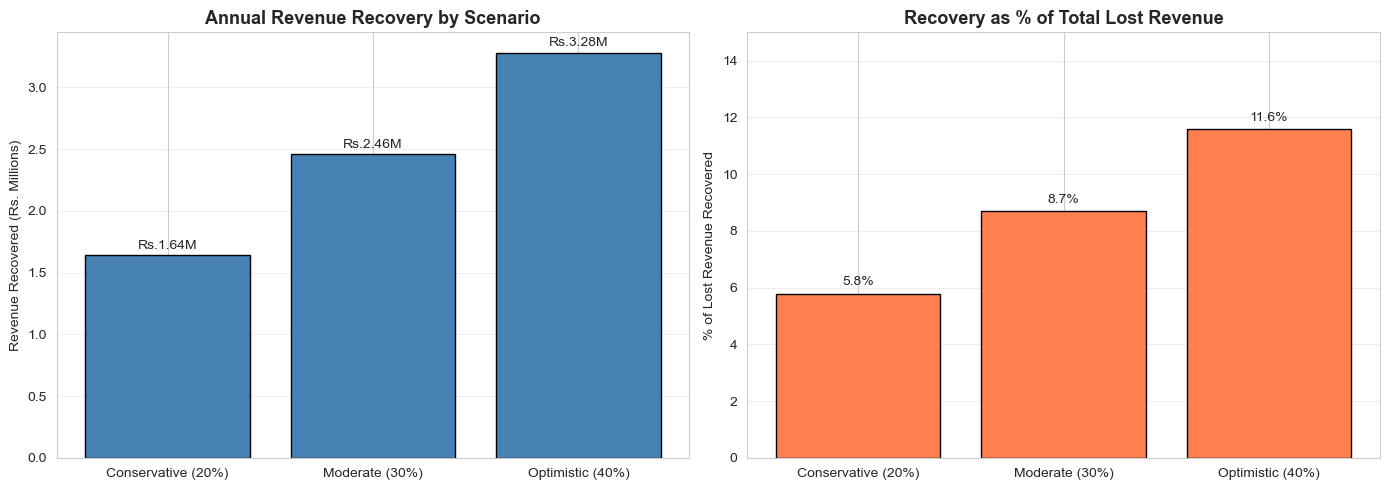

In [13]:
# Visualize scenarios
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Annual revenue recovery
scenarios_list = [r['Scenario'] for r in results]
annual_revenue = [r['Revenue (Annual)'] for r in results]

axes[0].bar(scenarios_list, annual_revenue, color='steelblue', edgecolor='black')
axes[0].set_ylabel('Revenue Recovered (Rs. Millions)')
axes[0].set_title('Annual Revenue Recovery by Scenario', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(annual_revenue):
    axes[0].text(i, v + 0.05, f'Rs.{v:.2f}M', ha='center')

# Percentage of lost revenue recovered
pct_recovered = [r['% of Lost Revenue'] for r in results]

axes[1].bar(scenarios_list, pct_recovered, color='coral', edgecolor='black')
axes[1].set_ylabel('% of Lost Revenue Recovered')
axes[1].set_title('Recovery as % of Total Lost Revenue', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 15])

for i, v in enumerate(pct_recovered):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.savefig('intervention_scenarios.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Feature-Based Recommendations

In [14]:
# Analyze feature importance
feature_names = ['hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour',
                'vehicle_type', 'pickup_location', 'drop_location', 
                'payment_method', 'time_of_day']

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

feature_importance_df = pd.DataFrame({
    'Feature': [feature_names[i] for i in indices],
    'Importance': [importances[i] for i in indices],
    'Importance %': [importances[i] * 100 for i in indices]
})

print("Feature Importance Analysis")
print("=" * 60)
print(feature_importance_df.to_string(index=False))

Feature Importance Analysis
        Feature  Importance  Importance %
 payment_method    0.732685     73.268463
  drop_location    0.070862      7.086171
pickup_location    0.070404      7.040361
           hour    0.034482      3.448155
          month    0.029417      2.941740
   vehicle_type    0.024301      2.430117
    day_of_week    0.021099      2.109860
    time_of_day    0.008612      0.861156
   is_peak_hour    0.004476      0.447559
     is_weekend    0.003664      0.366418


### Recommended Actions by Department

#### 1. Operations Team
**Immediate Actions:**
- Deploy real-time risk scoring for each booking
- Flag high-risk rides in dispatch system
- Allocate backup drivers for high-risk bookings

**Geographic Focus:**
- Analyze high-cancellation pickup/drop locations
- Increase driver availability in risk zones during peak hours
- Implement zone-specific incentives

#### 2. Product Team
**Payment Method Optimization** (73% feature importance):
- Promote reliable payment methods (UPI/Cards)
- Add payment verification before booking
- Offer incentives for pre-authorized payments

**User Experience:**
- Show ride reliability score at booking
- Implement smart driver-customer matching
- Add driver confirmation indicator

#### 3. Business Team
**Pricing Strategy:**
- Dynamic pricing for high-risk locations/times
- Risk-based cancellation fees
- Loyalty rewards for completion rates

**Driver Incentives:**
- Zone-based surge pricing
- Completion bonuses for difficult locations
- Peak hour guarantees

#### 4. Data Science Team
**Model Improvements:**
- Add historical driver/customer behavior features
- Incorporate real-time traffic/weather data
- Try XGBoost for marginal gains

**Deployment:**
- Build real-time API for risk scoring
- Set up A/B testing framework
- Monitor model drift
- Implement monthly retraining

## 6. Implementation Roadmap

### Phase 1 (Month 1-2): Foundation
- Deploy model as risk scoring API
- Integrate scores into dispatch dashboard  
- Manual review of high-risk rides
- Collect baseline intervention data

### Phase 2 (Month 3-4): Automation
- Automatic backup driver allocation
- Dynamic zone-based incentives
- Payment method recommendations
- A/B test intervention strategies

### Phase 3 (Month 5-6): Optimization
- Retrain with intervention results
- Optimize intervention thresholds
- Scale successful strategies
- Measure comprehensive ROI

### Success Metrics
**Primary:** Cancellation rate reduction  
**Secondary:** Revenue recovered  
**Tertiary:** Customer satisfaction improvement  
**Target:** 5-10% reduction in cancellations within 6 months

## Summary

### Current Situation
- 38% of rides unsuccessful (9,292 out of 24,449 in test set)
- Annual revenue loss: Rs.28.32M
- Primary issues: Driver cancellations (18%), Customer cancellations (7%)

### Model Capability
- Identifies 34.4% of high-risk rides before they occur
- Best at detecting driver cancellations (38% recall)
- Payment method is strongest predictor (73% importance)

### Revenue Opportunity
- Conservative scenario: Rs.1.63M annual recovery (5.8% of lost revenue)
- Moderate scenario: Rs.2.45M annual recovery (8.7% of lost revenue)
- Optimistic scenario: Rs.3.27M annual recovery (11.5% of lost revenue)

### Next Steps
1. Deploy model in production for real-time scoring
2. Implement payment method optimization
3. Focus operational improvements on high-risk zones
4. Set up A/B testing framework for interventions
5. Target 5-10% cancellation reduction in 6 months